# 02 EDA Main


## 1. Data


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="pastel", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED_PATH = ROOT / "data" / "processed" / "weight_perception_bmipct_cleaned.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load cleaned data created in 01_DataCheck.ipynb
# ------------------------------------------------------------
analysis = pd.read_csv(PROCESSED_PATH)

required_cols = ["PerceptionOfWeight", "WeightPerception", "BMIPCT"]
missing_cols = [col for col in required_cols if col not in analysis.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Please rerun 01_DataCheck.ipynb first.")

weight_perception_labels = {
    1: "Very underweight",
    2: "Slightly underweight",
    3: "About the right weight",
    4: "Slightly overweight",
    5: "Very overweight",
}
weight_perception_order = list(weight_perception_labels.values())

analysis["WeightPerception"] = pd.Categorical(
    analysis["WeightPerception"],
    categories=weight_perception_order,
    ordered=True
)

print("Rows in cleaned analysis data:", len(analysis))

Rows in cleaned analysis data: 12853


## 2. Group Summary


In [2]:
descriptive_statistics = (
    analysis
    .groupby(["PerceptionOfWeight", "WeightPerception"], observed=True)["BMIPCT"]
    .agg(
        sample_size="count",
        mean_bmipct="mean",
        sd_bmipct="std",
        median_bmipct="median",
        min_bmipct="min",
        max_bmipct="max"
    )
    .reset_index()
)

sample_size_lookup = (
    descriptive_statistics
    .assign(WeightPerception=descriptive_statistics["WeightPerception"].astype(str))
    .set_index("WeightPerception")["sample_size"]
    .to_dict()
)

weight_perception_labels_with_n = [
    f"{label}\n(n={int(sample_size_lookup[label]):,})"
    for label in weight_perception_order
]

descriptive_statistics.to_csv(TAB_DIR / "02_group_summary.csv", index=False)
display(descriptive_statistics)

,PerceptionOfWeight,WeightPerception,sample_size,mean_bmipct,sd_bmipct,median_bmipct,min_bmipct,max_bmipct
0,1,Very underweight,207,45.5037,35.0199,41.4927,0.0000,99.7522
1,2,Slightly underweight,1436,36.5332,25.7776,31.0726,0.0000,99.7984
2,3,About the right weight,7351,59.7139,24.2763,62.6423,0.0000,99.7347
3,4,Slightly overweight,3318,84.9890,16.4265,90.8859,0.0000,99.9392
4,5,Very overweight,541,92.2986,14.9535,98.1765,6.5508,99.9260


#### Interpretation

This table compares BMI percentile across the five perceived weight groups. The group means provide the first descriptive evidence for whether perceived weight category reflects actual BMI percentile.


## 3. Visualization 1: Boxplot of BMIPCT by Group


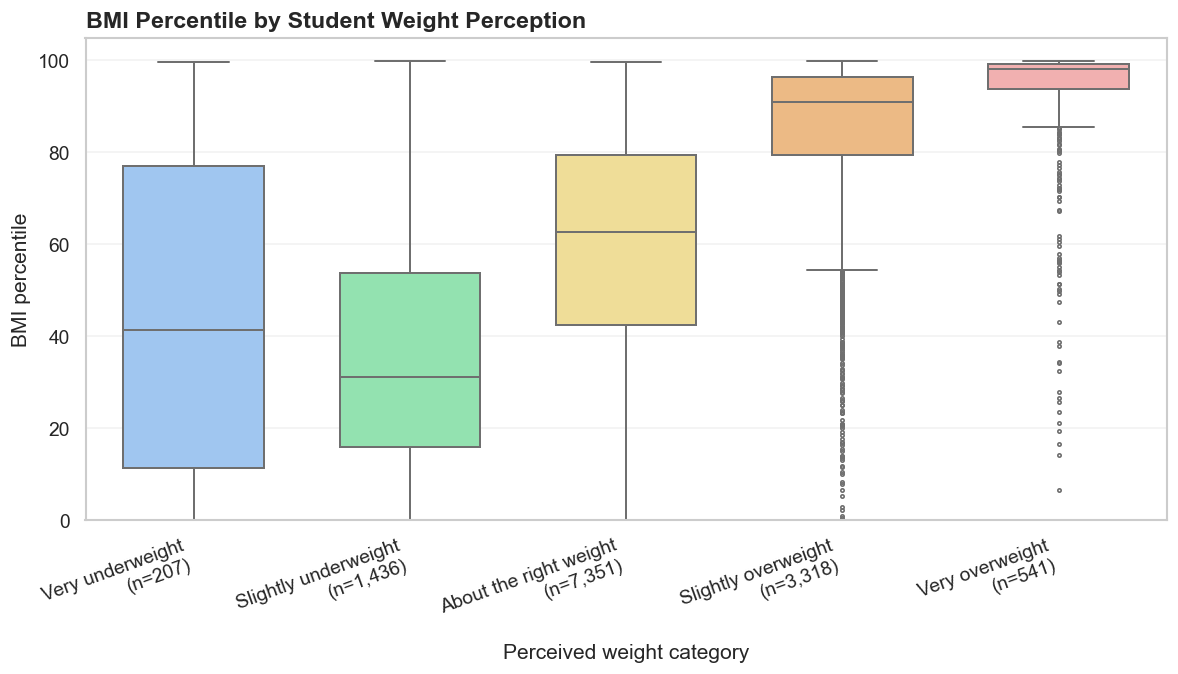

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.8))

sns.boxplot(
    data=analysis,
    x="WeightPerception",
    y="BMIPCT",
    order=weight_perception_order,
    hue="WeightPerception",
    hue_order=weight_perception_order,
    palette=["#93C5FD", "#86EFAC", "#FDE68A", "#FDBA74", "#FCA5A5"],
    width=0.65,
    linewidth=1.2,
    fliersize=2,
    legend=False,
    ax=ax,
)

ax.set_title("BMI Percentile by Student Weight Perception", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Perceived weight category")
ax.set_ylabel("BMI percentile")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)
ax.set_xticks(np.arange(len(weight_perception_order)))
ax.set_xticklabels(weight_perception_labels_with_n, rotation=20, ha="right")
plt.tight_layout()

boxplot_path = FIG_DIR / "bmipct_boxplot_by_weight_perception.png"
fig.savefig(boxplot_path, dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

The boxplot shows the distribution of BMI percentile in each perceived weight group. The overweight perception groups have visibly higher BMI percentiles overall, while the underweight groups tend to have lower BMI percentiles.


## 4. Visualization 2: Mean BMIPCT with 95% Confidence Intervals


,PerceptionOfWeight,WeightPerception,sample_size,mean_bmipct,sd_bmipct,median_bmipct,min_bmipct,max_bmipct,standard_error,t_critical,ci_95,ci_lower,ci_upper
0,1,Very underweight,207,45.5037,35.0199,41.4927,0.0000,99.7522,2.4341,1.9715,4.7989,40.7048,50.3025
1,2,Slightly underweight,1436,36.5332,25.7776,31.0726,0.0000,99.7984,0.6802,1.9616,1.3344,35.1988,37.8676
2,3,About the right weight,7351,59.7139,24.2763,62.6423,0.0000,99.7347,0.2831,1.9603,0.5550,59.1589,60.2689
3,4,Slightly overweight,3318,84.9890,16.4265,90.8859,0.0000,99.9392,0.2852,1.9607,0.5591,84.4298,85.5481
4,5,Very overweight,541,92.2986,14.9535,98.1765,6.5508,99.9260,0.6429,1.9644,1.2629,91.0357,93.5615


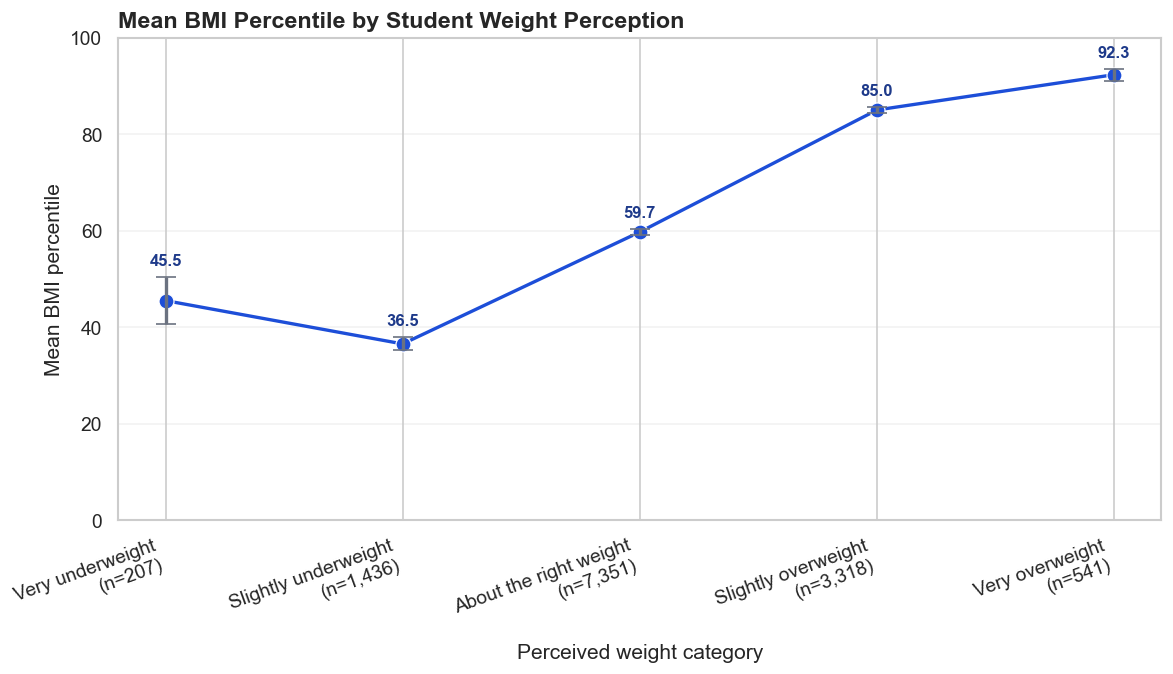

In [4]:
mean_ci_table = descriptive_statistics.copy()
mean_ci_table["standard_error"] = mean_ci_table["sd_bmipct"] / np.sqrt(mean_ci_table["sample_size"])
mean_ci_table["t_critical"] = stats.t.ppf(0.975, mean_ci_table["sample_size"] - 1)
mean_ci_table["ci_95"] = mean_ci_table["t_critical"] * mean_ci_table["standard_error"]
mean_ci_table["ci_lower"] = mean_ci_table["mean_bmipct"] - mean_ci_table["ci_95"]
mean_ci_table["ci_upper"] = mean_ci_table["mean_bmipct"] + mean_ci_table["ci_95"]

mean_ci_table.to_csv(TAB_DIR / "02_mean_bmipct_ci_table.csv", index=False)
display(mean_ci_table)

fig, ax = plt.subplots(figsize=(10, 5.8))

plot_table = mean_ci_table.copy()
plot_table["WeightPerception"] = pd.Categorical(
    plot_table["WeightPerception"],
    categories=weight_perception_order,
    ordered=True
)
plot_table = plot_table.sort_values("WeightPerception")

sns.lineplot(
    data=plot_table,
    x="WeightPerception",
    y="mean_bmipct",
    marker="o",
    markersize=9,
    linewidth=2,
    color="#1D4ED8",
    sort=False,
    ax=ax,
)

ax.errorbar(
    x=np.arange(len(plot_table)),
    y=plot_table["mean_bmipct"],
    yerr=plot_table["ci_95"],
    fmt="none",
    ecolor="#6B7280",
    elinewidth=2,
    capsize=6,
)

for index, row in plot_table.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["mean_bmipct"] + row["ci_95"] + 1.8,
        f'{row["mean_bmipct"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1E3A8A",
    )

ax.set_title("Mean BMI Percentile by Student Weight Perception", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Perceived weight category")
ax.set_ylabel("Mean BMI percentile")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.set_xticks(np.arange(len(weight_perception_order)))
ax.set_xticklabels(weight_perception_labels_with_n, rotation=20, ha="right")
plt.tight_layout()

mean_ci_path = FIG_DIR / "mean_bmipct_by_weight_perception_ci.png"
fig.savefig(mean_ci_path, dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

The mean BMI percentile increases across the higher perceived weight categories. This figure is useful for the one-slide summary because it directly connects the group variable to the quantitative response variable.


## 5. Visualization 3: Violin Plot of BMIPCT by Group

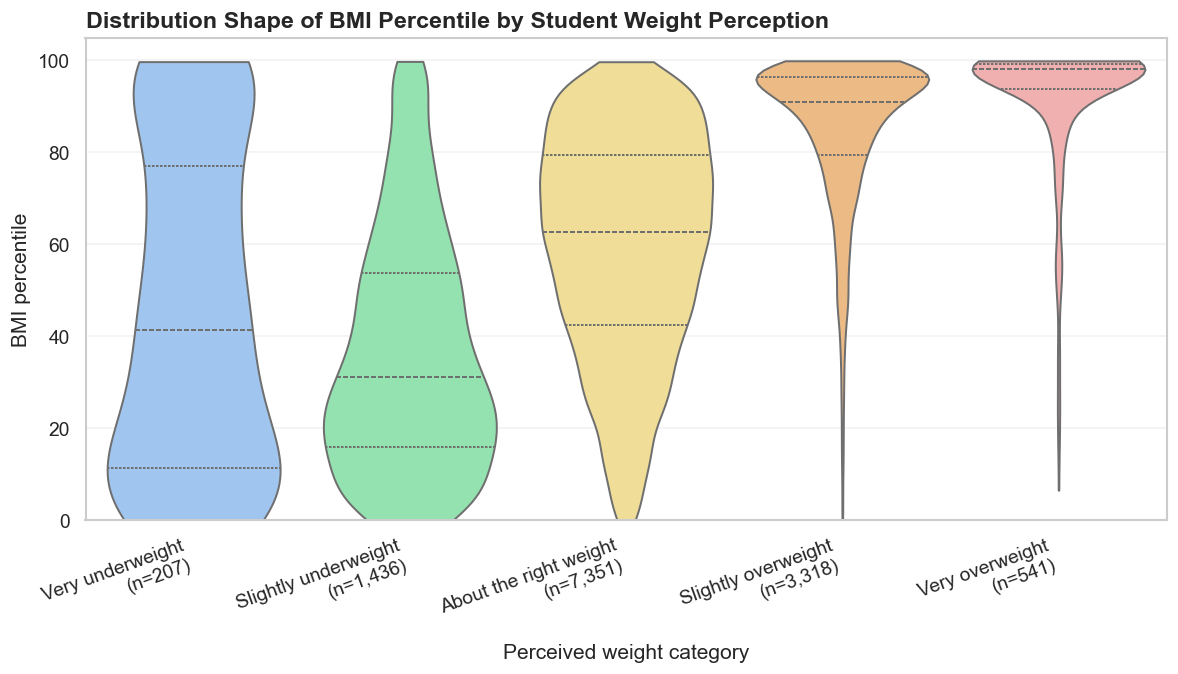

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.8))

sns.violinplot(
    data=analysis,
    x="WeightPerception",
    y="BMIPCT",
    order=weight_perception_order,
    hue="WeightPerception",
    hue_order=weight_perception_order,
    palette=["#93C5FD", "#86EFAC", "#FDE68A", "#FDBA74", "#FCA5A5"],
    inner="quartile",
    cut=0,
    linewidth=1.2,
    legend=False,
    ax=ax,
)

ax.set_title("Distribution Shape of BMI Percentile by Student Weight Perception", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Perceived weight category")
ax.set_ylabel("BMI percentile")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.25)
ax.set_xticks(np.arange(len(weight_perception_order)))
ax.set_xticklabels(weight_perception_labels_with_n, rotation=20, ha="right")
plt.tight_layout()

violin_path = FIG_DIR / "bmipct_violinplot_by_weight_perception.png"
fig.savefig(violin_path, dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation

The violin plot complements the boxplot by showing the full distribution shape within each group. It helps reveal where BMI percentile values are most densely concentrated and whether any group shows a wider or more complex shape, such as possible clustering across different BMI percentile ranges. This is especially useful for groups with large sample sizes and broad spreads.